# Model B — Keras TensorFlow: Accuracy Evaluation

This notebook tests `keras_model_with_5k_images.h5` against the validation dataset and produces:
- Overall **accuracy**, **precision**, **recall**, and **F1-score**
- **Confusion Matrix** heatmap
- **ROC Curve** with AUC score

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_curve, auc, accuracy_score
)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Configuration

In [2]:
# --- Paths ---
MODEL_PATH   = r'keras_model_with_5k_images.h5'
TEST_DIR     = r'..\Dataset\valid\images'   # contains sub-folders: Face / Non-Face

IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
CLASS_NAMES  = ['Face', 'Non-Face']          # must match folder names

print(f'Model  : {os.path.abspath(MODEL_PATH)}')
print(f'Test dir: {os.path.abspath(TEST_DIR)}')

Model  : d:\Final Year\Sem 2\Major Project\Model Project\Model B (Keras Tensorflow)\keras_model_with_5k_images.h5
Test dir: d:\Final Year\Sem 2\Major Project\Model Project\Dataset\valid\images


## 2. Load Model

In [3]:
model = load_model(MODEL_PATH)
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 1280)              410208    
                                                                 
 sequential_3 (Sequential)   (None, 2)                 128300    
                                                                 
Total params: 538508 (2.05 MB)
Trainable params: 524428 (2.00 MB)
Non-trainable params: 14080 (55.00 KB)
_________________________________________________________________


## 3. Load Test Data

In [4]:
# No augmentation for evaluation — only rescale
datagen = ImageDataGenerator(rescale=1.0 / 255.0)

test_gen = datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASS_NAMES,   # enforce label order: Face=0, Non-Face=1
    shuffle=False
)

print(f'\nClass indices: {test_gen.class_indices}')
print(f'Total images : {test_gen.samples}')

Found 2000 images belonging to 2 classes.

Class indices: {'Face': 0, 'Non-Face': 1}
Total images : 2000


## 4. Run Predictions

In [5]:
# Predict probabilities
y_prob = model.predict(test_gen, verbose=1)   # shape: (N, 2)

# True labels (one-hot → integer index)
y_true = test_gen.classes

# Predicted class indices
y_pred = np.argmax(y_prob, axis=1)

print(f'Samples predicted: {len(y_pred)}')

63/63 [==============================] - 23s 343ms/step
Samples predicted: 2000


## 5. Overall Accuracy & Classification Report

In [6]:
acc = accuracy_score(y_true, y_pred) * 100
print(f'\n=== Overall Accuracy: {acc:.2f}% ===\n')
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))


=== Overall Accuracy: 98.30% ===

              precision    recall  f1-score   support

        Face       0.98      0.98      0.98      1000
    Non-Face       0.98      0.98      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



## 6. Confusion Matrix

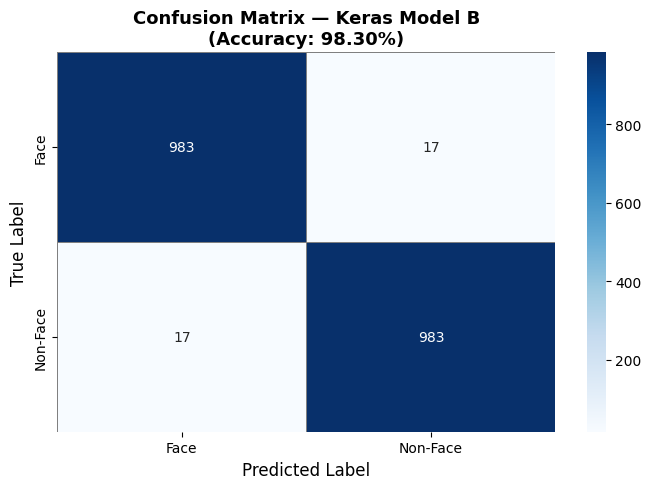

Saved: confusion_matrix.png


In [7]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'Confusion Matrix — Keras Model B\n(Accuracy: {acc:.2f}%)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

## 7. ROC Curve

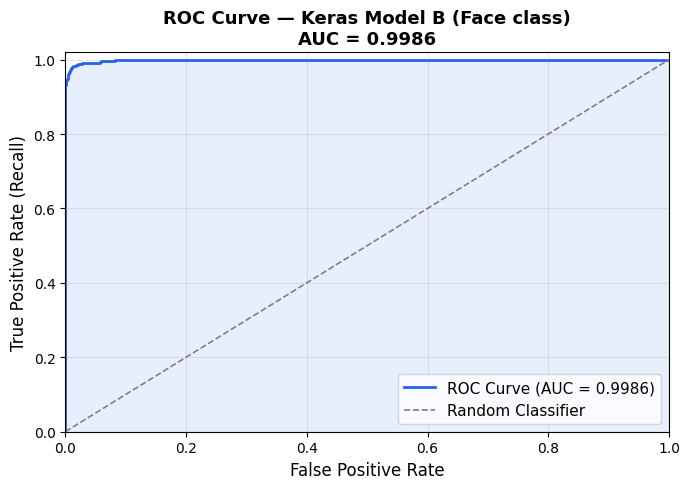

Saved: ROC.png


In [8]:
# ROC is computed for the positive class (Face = index 0)
# y_prob[:, 0] = probability of being a Face
# y_true == 0  = actual Face samples

fpr, tpr, thresholds = roc_curve(y_true, y_prob[:, 0], pos_label=0)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#2563EB', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='gray', lw=1.2, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.10, color='#2563EB')

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title(f'ROC Curve — Keras Model B (Face class)\nAUC = {roc_auc:.4f}', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ROC.png', dpi=150)
plt.show()
print('Saved: ROC.png')

## 8. Summary

In [9]:
TP = cm[0, 0]; FN = cm[0, 1]; FP = cm[1, 0]; TN = cm[1, 1]
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

print('=' * 40)
print('  Model B — Keras TensorFlow Summary')
print('=' * 40)
print(f'  Accuracy  : {acc:.2f}%')
print(f'  Precision : {precision * 100:.2f}%  (Face class)')
print(f'  Recall    : {recall * 100:.2f}%  (Face class)')
print(f'  F1-Score  : {f1 * 100:.2f}%  (Face class)')
print(f'  AUC       : {roc_auc:.4f}')
print('=' * 40)
print(f'  TP={TP}  FP={FP}  FN={FN}  TN={TN}')
print('=' * 40)

  Model B — Keras TensorFlow Summary
  Accuracy  : 98.30%
  Precision : 98.30%  (Face class)
  Recall    : 98.30%  (Face class)
  F1-Score  : 98.30%  (Face class)
  AUC       : 0.9986
  TP=983  FP=17  FN=17  TN=983
